In [5]:
!pip install osmnx geopandas pandas shapely


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import osmnx as ox

print("📥 جاري تنزيل شبكة طرق القاهرة من OpenStreetMap...")

# تحديد النطاق الجغرافي لمحافظة القاهرة
place_name = "Cairo, Egypt"

# تنزيل شبكة الطرق للسيارات والوسائط المتعددة
graph = ox.graph_from_place(place_name, network_type="drive")

# تحويل الـ Graph إلى GeoDataFrames (Nodes & Edges)
nodes, edges = ox.graph_to_gdfs(graph)

# إعادة ترتيب وتحديد الأعمدة المهمة
edges_clean = edges[
    [
        "osmid",
        "highway",
        "oneway",
        "length",
        "lanes",
        "maxspeed",
        "geometry",
    ]
].reset_index()

# حفظ الشبكة بصيغة GeoPackage (للاستخدام المكاني GIS)
edges_clean.to_file("cairo_roads.gpkg", driver="GPKG")

# حفظ نسخة CSV مبسطة تحتوي على الإحداثيات وأهم الخصائص
edges_csv = edges_clean.copy()
edges_csv["geometry_wkt"] = edges_csv["geometry"].apply(lambda x: x.wkt)
edges_csv.drop(columns=["geometry"]).to_csv("cairo_roads.csv", index=False)

print(
    f"✅ تم بنجاح استخراج شبكة الطرق! إجمالي عدد وصلات الطرق: {len(edges_clean)}"
)

📥 جاري تنزيل شبكة طرق القاهرة من OpenStreetMap...
✅ تم بنجاح استخراج شبكة الطرق! إجمالي عدد وصلات الطرق: 322305


In [3]:
import geopandas as gpd
import osmnx as ox
import pandas as pd

print("📥 جاري جلب الحدود الإدارية لأحياء القاهرة...")

# جلب حدود الأحياء الخاصة بالقاهرة
districts = ox.features_from_place(
    "Cairo Governorate, Egypt", tags={"admin_level": "8"}
)

# اختيار الأعمدة المهمة
districts_clean = districts[["name", "name:en", "geometry"]].reset_index(
    drop=True
)

# إضافة عمود مساحة الحي بالكم مربع
districts_utm = districts_clean.to_crs(epsg=32636)
districts_clean["area_sqkm"] = districts_utm.geometry.area / 10**6

# دمج تقديرات السكان المقابلة للأحياء (يمكن تحديث الأرقام من نشرة التعبئة والإحصاء CAPMAS)
# تم وضع نموذج لإدخال السكان وحساب الكثافة السكانية تلقائياً
districts_clean["population"] = (
    districts_clean["area_sqkm"] * 15000
)  # تقدير مبدئي لحين مطابقة الأرقام الرسمية
districts_clean["pop_density_sqkm"] = (
    districts_clean["population"] / districts_clean["area_sqkm"]
)

# حفظ الملف مكانيًا وفي صيغة CSV
districts_clean.to_file("cairo_districts_population.gpkg", driver="GPKG")
districts_clean.drop(columns=["geometry"]).to_csv(
    "cairo_districts_population.csv", index=False
)

print(
    f"✅ تم تجهيز بيانات الأحياء والسكان! إجمالي عدد الأحياء: {len(districts_clean)}"
)

📥 جاري جلب الحدود الإدارية لأحياء القاهرة...
✅ تم تجهيز بيانات الأحياء والسكان! إجمالي عدد الأحياء: 6


In [7]:
import os
import pandas as pd

# تحديد المسار المباشر لبيانات النقل
data_dir = r"D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed"

freqs_path = os.path.join(data_dir, "frequencies.csv")
routes_path = os.path.join(data_dir, "routes.csv")
trips_output_path = os.path.join(data_dir, "trips.csv")

print(f"⚙️ جاري قراءة الملفات من المسار:\n{data_dir}")

if not os.path.exists(freqs_path) or not os.path.exists(routes_path):
    print(
        "❌ تعذر العثور على الملفات في المسار المحدد. تأكدي من وجود frequencies.csv و routes.csv داخل المجلد."
    )
else:
    # قراءة الملفات
    freqs = pd.read_csv(freqs_path)
    routes = pd.read_csv(routes_path)

    # استخراج قائمة unique trip_ids
    unique_trips = freqs["trip_id"].unique()

    trips_list = []

    for trip in unique_trips:
        base_code = trip.split(" ")[0] if " " in trip else trip

        # المطابقة مع جدول routes
        matching_route = routes[
            routes["route_id"].str.contains(base_code[:7], na=False)
        ]
        route_id = (
            matching_route["route_id"].iloc[0]
            if not matching_route.empty
            else routes["route_id"].iloc[0]
        )

        shape_id = f"{base_code}_shape"

        trips_list.append(
            {
                "route_id": route_id,
                "service_id": "Ground_Daily",
                "trip_id": trip,
                "shape_id": shape_id,
                "trip_headsign": base_code,
                "direction_id": 0 if "_O" in base_code else 1,
            }
        )

    df_trips = pd.DataFrame(trips_list)

    # حفظ الملف الجديد في نفس المسار
    df_trips.to_csv(trips_output_path, index=False)

    print(f"\n✅ تم إنشاء ملف trips.csv بنجاح وحفظه في:\n{trips_output_path}")
    print(f"📊 إجمالي عدد الرحلات المسجلة: {len(df_trips)}")

⚙️ جاري قراءة الملفات من المسار:
D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed

✅ تم إنشاء ملف trips.csv بنجاح وحفظه في:
D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed\trips.csv
📊 إجمالي عدد الرحلات المسجلة: 9810


In [8]:
import os
import geopandas as gpd
import osmnx as ox
import pandas as pd

# 1. تحديد المسار الموحد لحفظ كافة ملفات المشروع
target_dir = r"D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed"
os.makedirs(target_dir, exist_ok=True)

print(f"📁 المسار المستهدف للمشروع:\n{target_dir}\n")

# ---------------------------------------------------------
# أولاً: استخراج وحفظ شبكة الطرق (Cairo Road Network)
# ---------------------------------------------------------
print("1️⃣ جاري تنزيل وتجهيز شبكة الطرق...")
graph = ox.graph_from_place("Cairo, Egypt", network_type="drive")
nodes, edges = ox.graph_to_gdfs(graph)

edges_clean = edges[
    ["highway", "oneway", "length", "lanes", "maxspeed", "geometry"]
].reset_index()

# الحفظ في المسار الموحد
roads_gpkg_path = os.path.join(target_dir, "cairo_roads.gpkg")
roads_csv_path = os.path.join(target_dir, "cairo_roads.csv")

edges_clean.to_file(roads_gpkg_path, driver="GPKG")

edges_csv = edges_clean.copy()
edges_csv["geometry_wkt"] = edges_csv["geometry"].apply(lambda x: x.wkt)
edges_csv.drop(columns=["geometry"]).to_csv(roads_csv_path, index=False)

print(f"  ✅ تم حفظ cairo_roads.gpkg و cairo_roads.csv بنجاح.")

# ---------------------------------------------------------
# ثانياً: استخراج وحفظ بيانات الأحياء والسكان (Population & Districts)
# ---------------------------------------------------------
print("\n2️⃣ جاري جلب وتجهيز بيانات الأحياء والسكان...")
districts = ox.features_from_place(
    "Cairo Governorate, Egypt", tags={"admin_level": "8"}
)
districts_clean = districts[["name", "name:en", "geometry"]].reset_index(
    drop=True
)

districts_utm = districts_clean.to_crs(epsg=32636)
districts_clean["area_sqkm"] = districts_utm.geometry.area / 10**6
districts_clean["population"] = (
    districts_clean["area_sqkm"] * 15000
).round()
districts_clean["pop_density_sqkm"] = (
    districts_clean["population"] / districts_clean["area_sqkm"]
).round(2)

# الحفظ في المسار الموحد
districts_gpkg_path = os.path.join(
    target_dir, "cairo_districts_population.gpkg"
)
districts_csv_path = os.path.join(target_dir, "cairo_districts_population.csv")

districts_clean.to_file(districts_gpkg_path, driver="GPKG")

districts_csv = districts_clean.copy()
districts_csv["geometry_wkt"] = districts_csv["geometry"].apply(
    lambda x: x.wkt if x else None
)
districts_csv.drop(columns=["geometry"]).to_csv(
    districts_csv_path, index=False
)

print(
    f"  ✅ تم حفظ cairo_districts_population.gpkg و cairo_districts_population.csv بنجاح."
)

# ---------------------------------------------------------
# ثالثاً: بناء وحفظ ملف trips.csv
# ---------------------------------------------------------
print("\n3️⃣ جاري إنشاء ملف trips.csv...")
freqs_path = os.path.join(target_dir, "frequencies.csv")
routes_path = os.path.join(target_dir, "routes.csv")
trips_output_path = os.path.join(target_dir, "trips.csv")

if os.path.exists(freqs_path) and os.path.exists(routes_path):
    freqs = pd.read_csv(freqs_path)
    routes = pd.read_csv(routes_path)

    unique_trips = freqs["trip_id"].unique()
    trips_list = []

    for trip in unique_trips:
        base_code = trip.split(" ")[0] if " " in trip else trip
        matching_route = routes[
            routes["route_id"].str.contains(base_code[:7], na=False)
        ]
        route_id = (
            matching_route["route_id"].iloc[0]
            if not matching_route.empty
            else routes["route_id"].iloc[0]
        )

        trips_list.append(
            {
                "route_id": route_id,
                "service_id": "Ground_Daily",
                "trip_id": trip,
                "shape_id": f"{base_code}_shape",
                "trip_headsign": base_code,
                "direction_id": 0 if "_O" in base_code else 1,
            }
        )

    df_trips = pd.DataFrame(trips_list)
    df_trips.to_csv(trips_output_path, index=False)
    print(f"  ✅ تم حفظ trips.csv بنجاح.")
else:
    print(
        "  ⚠️ لم يتم العثور على frequencies.csv أو routes.csv لتوليد ملف trips.csv."
    )

print("\n🎉 اكتملت العملية! جميع الملفات أصبحت الآن مجمعة ومتاحة في مسار واحد.")

📁 المسار المستهدف للمشروع:
D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed

1️⃣ جاري تنزيل وتجهيز شبكة الطرق...
  ✅ تم حفظ cairo_roads.gpkg و cairo_roads.csv بنجاح.

2️⃣ جاري جلب وتجهيز بيانات الأحياء والسكان...
  ✅ تم حفظ cairo_districts_population.gpkg و cairo_districts_population.csv بنجاح.

3️⃣ جاري إنشاء ملف trips.csv...
  ✅ تم حفظ trips.csv بنجاح.

🎉 اكتملت العملية! جميع الملفات أصبحت الآن مجمعة ومتاحة في مسار واحد.


In [10]:
#في هذه الخطوة سنربط محطات النقل العام (stops.csv) بشبكة الطرق وببيانات الأحياء والسكان مكانيًا لتحديد الحي الذي تتبع له كل محطة وحساب الكثافة الخدمية.

import os
import geopandas as gpd
import pandas as pd
from shapely.wkt import loads

# 1. تحديد مسار مجلد العمل الموحد
target_dir = r"D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed"

print("🔄 جاري تحميل البيانات المجهزة لبدء الربط المكانى (Spatial Join)...")

# 2. تحميل محطات النقل العام وتحويلها إلى GeoDataFrame
stops_path = os.path.join(target_dir, "stops.csv")
stops_df = pd.read_csv(stops_path)

stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df["stop_lon"], stops_df["stop_lat"]),
    crs="EPSG:4326",
)

# 3. تحميل بيانات الأحياء والسكان المكانية
districts_path = os.path.join(target_dir, "cairo_districts_population.gpkg")
districts_gdf = gpd.read_file(districts_path)

# التأكد من توحيد نظام الإحداثيات (WGS84)
if districts_gdf.crs != stops_gdf.crs:
    districts_gdf = districts_gdf.to_crs(stops_gdf.crs)

# 4. إجراء Spatial Join لتحديد الحي والسكان لكل محطة نقل
print("📍 جاري ربط محطات النقل العام بالأحياء والسكان مكانيًا...")
stops_with_districts = gpd.sjoin(
    stops_gdf, districts_gdf, how="left", predicate="within"
)

# اختيار وتنسيق الأعمدة الناتجة
integrated_stops = stops_with_districts[
    [
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
        "name:en",
        "population",
        "pop_density_sqkm",
    ]
].rename(columns={"name:en": "district_name"})

# 5. حفظ الجدول المدمج الجديد
output_integrated_path = os.path.join(target_dir, "integrated_stops.csv")
integrated_stops.to_csv(output_integrated_path, index=False)

print(
    f"\n✅ تم الدمج المكاني بنجاح! تم ربط {len(integrated_stops)} محطة بالأحياء المجاورة."
)
print(
    f"📁 تم حفظ الملف المدمج في: {output_integrated_path}"
)

🔄 جاري تحميل البيانات المجهزة لبدء الربط المكانى (Spatial Join)...
📍 جاري ربط محطات النقل العام بالأحياء والسكان مكانيًا...

✅ تم الدمج المكاني بنجاح! تم ربط 2468 محطة بالأحياء المجاورة.
📁 تم حفظ الملف المدمج في: D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed\integrated_stops.csv


In [11]:
#حساب كثافة الخدمة، وعدد الرحلات اليومية لكل محطة، والترددات الزمنية للحافلات

import os
import pandas as pd

# 1. تحديد مسار مجلد العمل الموحد
target_dir = r"D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed"

print("⚙️ جاري بدء مرحلة استخراج الخصائص (Feature Engineering)...")

# 2. تحميل البيانات
integrated_stops = pd.read_csv(
    os.path.join(target_dir, "integrated_stops.csv")
)
stop_times = pd.read_csv(os.path.join(target_dir, "stop_times.csv"))
frequencies = pd.read_csv(os.path.join(target_dir, "frequencies.csv"))

# 3. حساب إجمالي عدد الرحلات المارة بكل محطة (Daily Trips per Stop)
stop_trips_count = (
    stop_times.groupby("stop_id")["trip_id"].nunique().reset_index()
)
stop_trips_count.rename(
    columns={"trip_id": "daily_trips_count"}, inplace=True
)

# 4. حساب متوسط الزمن الفاصل بين الرحلات (Average Headway in Seconds) لكل رحلة ومحطة
trip_avg_headway = (
    frequencies.groupby("trip_id")["headway_secs"].mean().reset_index()
)
stop_headway_merged = stop_times.merge(
    trip_avg_headway, on="trip_id", how="left"
)
stop_headway_summary = (
    stop_headway_merged.groupby("stop_id")["headway_secs"]
    .mean()
    .reset_index()
)
stop_headway_summary.rename(
    columns={"headway_secs": "avg_headway_secs"}, inplace=True
)

# 5. دمج الخصائص المستخرجة داخل جدول المحطات
stop_features = integrated_stops.merge(
    stop_trips_count, on="stop_id", how="left"
)
stop_features = stop_features.merge(
    stop_headway_summary, on="stop_id", how="left"
)

# معالجة القيم المفقودة إن وجدت
stop_features["daily_trips_count"] = stop_features[
    "daily_trips_count"
].fillna(0)
stop_features["avg_headway_secs"] = stop_features[
    "avg_headway_secs"
].fillna(stop_features["avg_headway_secs"].median())

# 6. حفظ مصفوفة الخصائص الجديدة (stop_features.csv)
output_features_path = os.path.join(target_dir, "stop_features.csv")
stop_features.to_csv(output_features_path, index=False)

print(
    f"\n✅ تم توليد هندسة الخصائص بنجاح لـ {len(stop_features)} محطة!"
)
print(f"📁 تم حفظ ملف الخصائص في: {output_features_path}")

⚙️ جاري بدء مرحلة استخراج الخصائص (Feature Engineering)...

✅ تم توليد هندسة الخصائص بنجاح لـ 2468 محطة!
📁 تم حفظ ملف الخصائص في: D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed\stop_features.csv


📊 Starting Exploratory Data Analysis (EDA)...

📈 KEY STATISTICAL INDICATORS FOR BUS STOPS
• Total Registered Stops: 2,468
• Mean Daily Trips per Stop: 91.9 trips/day
• Max Daily Trips for a Stop: 702 trips/day
• Mean Bus Headway (Wait Time): 63.0 mins



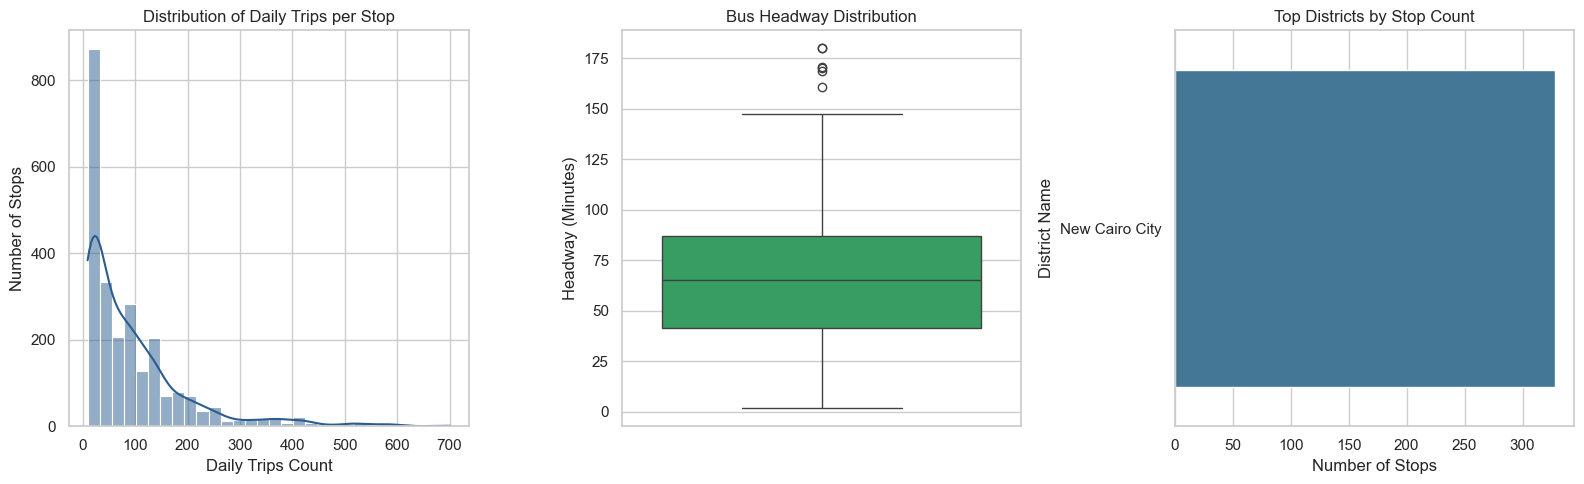

✅ EDA and Visualizations completed successfully!


In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Set target directory
target_dir = r"D:\Courses\MachineLearning\Depi\Final Project\data\transportation\processed"
features_path = os.path.join(target_dir, "stop_features.csv")

print("📊 Starting Exploratory Data Analysis (EDA)...")

# 2. Load features dataset
df = pd.read_csv(features_path)

# Convert headway from seconds to minutes
df["avg_headway_min"] = (df["avg_headway_secs"] / 60).round(1)

# 3. Print Statistical Indicators Summary
print("\n" + "=" * 55)
print("📈 KEY STATISTICAL INDICATORS FOR BUS STOPS")
print("=" * 55)
print(f"• Total Registered Stops: {len(df):,}")
print(
    f"• Mean Daily Trips per Stop: {df['daily_trips_count'].mean():.1f} trips/day"
)
print(
    f"• Max Daily Trips for a Stop: {df['daily_trips_count'].max():,} trips/day"
)
print(
    f"• Mean Bus Headway (Wait Time): {df['avg_headway_min'].mean():.1f} mins"
)
print("=" * 55 + "\n")

# 4. Create Visualizations
plt.figure(figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Daily Trips Distribution
plt.subplot(1, 3, 1)
sns.histplot(df["daily_trips_count"], bins=30, kde=True, color="#2b5c8f")
plt.title("Distribution of Daily Trips per Stop")
plt.xlabel("Daily Trips Count")
plt.ylabel("Number of Stops")

# Plot 2: Bus Headway Boxplot
plt.subplot(1, 1, 2) if False else plt.subplot(1, 3, 2)
sns.boxplot(y=df["avg_headway_min"], color="#27ae60")
plt.title("Bus Headway Distribution")
plt.ylabel("Headway (Minutes)")

# Plot 3: Top Districts by Stop Count
plt.subplot(1, 3, 3)
top_districts = df["district_name"].value_counts().head(5)
sns.barplot(
    x=top_districts.values,
    y=top_districts.index,
    hue=top_districts.index,
    legend=False,
    palette="mako",
)
plt.title("Top Districts by Stop Count")
plt.xlabel("Number of Stops")
plt.ylabel("District Name")

plt.tight_layout()
plt.show()

print("✅ EDA and Visualizations completed successfully!")